
# ASPICE Repository Readiness — Complete Single Notebook

This notebook mines four public automotive repositories, aggregates monthly Git metrics,
constructs a repository-derived ASPICE readiness proxy, performs EDA, and saves dissertation-ready outputs.

**Important:** The readiness score is a repository-derived proxy, not a formal ASPICE assessment.


In [ ]:
!pip install -q pydriller statsmodels scipy scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00


In [5]:
import os, math, time, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pydriller import Repository
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

REPO_URLS = [
    "https://github.com/ApolloAuto/apollo.git",
    "https://github.com/autowarefoundation/autoware.git",
    "https://gitlab.eclipse.org/eclipse/openpass/opSimulation.git",
    "https://github.com/eclipse-sumo/sumo.git",
]
SINCE_DATE = None
MAX_COMMITS_PER_REPOSITORY = 300
AGGREGATION_WINDOW = "M"

RAW_DATA_PATH = "./data/raw"
PROCESSED_DATA_PATH = "./data/processed"
EDA_FIGURE_PATH = "./figures/repository_eda"
EDA_TABLE_PATH = "./tables/repository_eda"

for p in [RAW_DATA_PATH, PROCESSED_DATA_PATH, EDA_FIGURE_PATH, EDA_TABLE_PATH]:
    os.makedirs(p, exist_ok=True)

TARGET_COLUMN = "aspice_readiness_level"
SCORE_COLUMN = "repository_aspice_readiness_score"

print("Configuration loaded.")

Configuration loaded.


In [6]:
def repo_name(url):
    return url.rstrip("/").removesuffix(".git").split("/")[-1]

def extract_commit_data(repo_url, since_date=None, max_commits=300):
    name = repo_name(repo_url)
    records = []
    print("\n" + "-"*80)
    print(f"Mining repository: {name}")
    print(repo_url)
    print("-"*80)
    try:
        kwargs = {"path_to_repo": repo_url, "only_no_merge": False}
        if since_date is not None:
            kwargs["since"] = since_date
        for i, commit in enumerate(Repository(**kwargs).traverse_commits(), start=1):
            if max_commits is not None and i > max_commits:
                break
            if i <= 5 or i % 50 == 0:
                print(f"Processing commit {i}: {commit.hash[:10]}", flush=True)
            author = getattr(commit, "author", None)
            parents = getattr(commit, "parents", []) or []
            ins = getattr(commit, "insertions", 0) or 0
            dels = getattr(commit, "deletions", 0) or 0
            lines = getattr(commit, "lines", None)
            if lines is None:
                lines = ins + dels
            files = getattr(commit, "files", None)
            if files is None:
                files = len(getattr(commit, "modified_files", []) or [])
            records.append({
                "repository_name": name,
                "repository_url": repo_url,
                "commit_hash": commit.hash,
                "author_name": getattr(author, "name", "Unknown") if author else "Unknown",
                "author_email": getattr(author, "email", None) if author else None,
                "committer_date": getattr(commit, "committer_date", None),
                "lines_added": ins,
                "lines_deleted": dels,
                "lines_modified": lines,
                "files_changed": files or 0,
                "is_merge_commit": len(parents) > 1,
                "dmm_unit_size": getattr(commit, "dmm_unit_size", np.nan),
                "dmm_unit_complexity": getattr(commit, "dmm_unit_complexity", np.nan),
            })
        out = pd.DataFrame(records)
        if out.empty:
            print(f"No commits extracted from {name}.")
            return out
        out["committer_date"] = pd.to_datetime(out["committer_date"], errors="coerce", utc=True)
        print(f"Successfully extracted {len(out)} commits from {name}.")
        return out
    except Exception as e:
        print(f"Repository extraction failed for {name}: {e}")
        return pd.DataFrame()

def extract_all_repositories(repo_urls, since_date=None, max_commits_per_repository=300):
    frames, log = [], []
    for url in repo_urls:
        start = time.time()
        d = extract_commit_data(url, since_date, max_commits_per_repository)
        log.append({
            "repository_name": repo_name(url),
            "repository_url": url,
            "records_extracted": len(d),
            "status": "Success" if not d.empty else "Failed or empty",
            "extraction_seconds": round(time.time()-start, 2),
        })
        if not d.empty:
            frames.append(d)
    log_df = pd.DataFrame(log)
    display(log_df)
    if not frames:
        raise RuntimeError("No repository data extracted.")
    commits = pd.concat(frames, ignore_index=True)
    commits.to_csv(os.path.join(RAW_DATA_PATH, "all_repository_commits.csv"), index=False)
    log_df.to_csv(os.path.join(PROCESSED_DATA_PATH, "repository_extraction_log.csv"), index=False)
    return commits, log_df

In [7]:
def aggregate_repository_metrics(commits_df, aggregation_window="M"):
    d = commits_df.dropna(subset=["committer_date"]).copy()
    d["observation_period"] = (
        d["committer_date"].dt.tz_convert(None).dt.to_period(aggregation_window).dt.to_timestamp()
    )
    g = (
        d.groupby(["repository_name", "repository_url", "observation_period"])
        .agg(
            total_commits=("commit_hash", "count"),
            commit_frequency=("commit_hash", "count"),
            unique_authors=("author_email", "nunique"),
            avg_commit_size=("lines_modified", "mean"),
            code_churn=("lines_modified", "sum"),
            avg_files_per_commit=("files_changed", "mean"),
            merge_commits=("is_merge_commit", "sum"),
            avg_dmm_unit_size=("dmm_unit_size", "mean"),
            avg_dmm_complexity=("dmm_unit_complexity", "mean"),
        )
        .reset_index()
    )
    g["merge_commit_rate"] = g["merge_commits"] / g["total_commits"].replace(0, np.nan)
    g["project_id"] = g["repository_name"] + "-" + g["observation_period"].dt.strftime("%Y-%m")
    g["dataset_type"] = "Public repository-derived"
    cols = [
        "project_id","repository_name","repository_url","observation_period","dataset_type",
        "total_commits","commit_frequency","unique_authors","avg_commit_size","code_churn",
        "avg_files_per_commit","merge_commit_rate","avg_dmm_unit_size","avg_dmm_complexity"
    ]
    g = g[cols]
    g.to_csv(os.path.join(PROCESSED_DATA_PATH, "repository_window_dataset.csv"), index=False)
    print(f"Created {len(g)} repository-window observations.")
    return g

def run_public_repository_pipeline():
    print("="*80)
    print("PUBLIC REPOSITORY ASPICE PIPELINE")
    print("="*80)
    commits, log = extract_all_repositories(
        REPO_URLS, SINCE_DATE, MAX_COMMITS_PER_REPOSITORY
    )
    final_dataset = aggregate_repository_metrics(commits, AGGREGATION_WINDOW)
    print(f"Commit records: {len(commits)}")
    print(f"Repository-window observations: {len(final_dataset)}")
    return {"commit_dataset": commits, "extraction_log": log, "final_dataset": final_dataset}

pipeline_results = run_public_repository_pipeline()
df = pipeline_results["final_dataset"].copy()
print("Repository dataset shape:", df.shape)
print("Repositories:", df["repository_name"].unique())
display(df.head())

PUBLIC REPOSITORY ASPICE PIPELINE

--------------------------------------------------------------------------------
Mining repository: apollo
https://github.com/ApolloAuto/apollo.git
--------------------------------------------------------------------------------
Processing commit 1: d7f6e9b9cf
Processing commit 2: 475fc67532
Processing commit 3: 219af8c8ef
Processing commit 4: 5d0e7f48e3
Processing commit 5: 0f54071b24
Processing commit 50: eadbeb78dd
Processing commit 100: a9b5ac1bd9
Processing commit 150: 94a2d0ef63
Processing commit 200: 15849b4be2
Processing commit 250: ed540f7f64
Processing commit 300: 93cc709d8f
Successfully extracted 300 commits from apollo.

--------------------------------------------------------------------------------
Mining repository: autoware
https://github.com/autowarefoundation/autoware.git
--------------------------------------------------------------------------------
Processing commit 1: 15a62b0997
Processing commit 2: de2053bcb8
Processing commit 3

,repository_name,repository_url,records_extracted,status,extraction_seconds
0,apollo,https://github.com/ApolloAuto/apollo.git,300,Success,214.75
1,autoware,https://github.com/autowarefoundation/autoware...,300,Success,6.29
2,opSimulation,https://gitlab.eclipse.org/eclipse/openpass/op...,300,Success,215.26
3,sumo,https://github.com/eclipse-sumo/sumo.git,300,Success,531.67


Created 62 repository-window observations.
Commit records: 1200
Repository-window observations: 62
Repository dataset shape: (62, 14)
Repositories: ['apollo' 'autoware' 'opSimulation' 'sumo']


,project_id,repository_name,repository_url,observation_period,dataset_type,total_commits,commit_frequency,unique_authors,avg_commit_size,code_churn,avg_files_per_commit,merge_commit_rate,avg_dmm_unit_size,avg_dmm_complexity
0,apollo-2017-07,apollo,https://github.com/ApolloAuto/apollo.git,2017-07-01,Public repository-derived,300,300,28,8300.253333,2490076,7.450,0.053333,0.590469,0.723146
1,autoware-2021-11,autoware,https://github.com/autowarefoundation/autoware...,2021-11-01,Public repository-derived,1,1,1,28.000000,28,1.000,0.000000,NaN,NaN
2,autoware-2021-12,autoware,https://github.com/autowarefoundation/autoware...,2021-12-01,Public repository-derived,1,1,1,661.000000,661,12.000,0.000000,NaN,NaN
3,autoware-2022-01,autoware,https://github.com/autowarefoundation/autoware...,2022-01-01,Public repository-derived,14,14,3,76.642857,1073,5.500,0.000000,NaN,NaN
4,autoware-2022-02,autoware,https://github.com/autowarefoundation/autoware...,2022-02-01,Public repository-derived,24,24,7,40.000000,960,2.125,0.000000,NaN,NaN


In [8]:
def percentile_score(series, higher_is_better=True):
    s = pd.to_numeric(series, errors="coerce").rank(method="average", pct=True) * 100
    return s if higher_is_better else 100-s

def bounded_percentile_score(series):
    x = pd.to_numeric(series, errors="coerce")
    med, q10, q90 = x.median(), x.quantile(.10), x.quantile(.90)
    dist = max(abs(q10-med), abs(q90-med), 1e-9)
    return ((1 - abs(x-med)/dist) * 100).clip(0,100)

def build_repository_readiness_dataset(dataframe):
    r = dataframe.copy()
    needed = ["commit_frequency","unique_authors","avg_commit_size","code_churn",
              "avg_files_per_commit","merge_commit_rate"]
    missing = [c for c in needed if c not in r.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    r["indicator_planning_effectiveness"] = percentile_score(r["commit_frequency"], True)
    r["indicator_team_collaboration"] = percentile_score(r["unique_authors"], True)
    r["indicator_coding_discipline"] = percentile_score(r["avg_commit_size"], False)
    r["indicator_implementation_stability"] = bounded_percentile_score(r["code_churn"])
    r["indicator_change_manageability"] = percentile_score(r["avg_files_per_commit"], False)
    r["indicator_configuration_management"] = bounded_percentile_score(r["merge_commit_rate"])
    if "avg_dmm_complexity" in r and r["avg_dmm_complexity"].notna().sum() >= 3:
        r["indicator_design_quality"] = percentile_score(r["avg_dmm_complexity"], False)
    else:
        r["indicator_design_quality"] = np.nan
    r["author_diversity_ratio"] = r["unique_authors"] / r["commit_frequency"].replace(0,np.nan)
    r["indicator_resource_distribution"] = percentile_score(r["author_diversity_ratio"], True)

    r["proxy_SWE_1_score"] = r[["indicator_planning_effectiveness","indicator_change_manageability"]].mean(axis=1)
    r["proxy_SWE_2_3_score"] = r[["indicator_implementation_stability","indicator_coding_discipline","indicator_design_quality"]].mean(axis=1, skipna=True)
    r["proxy_SWE_4_score"] = r[["indicator_coding_discipline","indicator_change_manageability"]].mean(axis=1)
    r["proxy_SWE_5_score"] = r[["indicator_configuration_management","indicator_implementation_stability"]].mean(axis=1)
    r["proxy_SUP_1_8_score"] = r[["indicator_configuration_management","indicator_change_manageability","indicator_team_collaboration"]].mean(axis=1)
    r["proxy_MAN_3_score"] = r[["indicator_planning_effectiveness","indicator_team_collaboration","indicator_resource_distribution"]].mean(axis=1)

    weights = {
        "proxy_SWE_1_score": .15, "proxy_SWE_2_3_score": .20, "proxy_SWE_4_score": .15,
        "proxy_SWE_5_score": .20, "proxy_SUP_1_8_score": .15, "proxy_MAN_3_score": .15
    }
    weighted_sum = pd.Series(0.0, index=r.index)
    available = pd.Series(0.0, index=r.index)
    for c,w in weights.items():
        valid = r[c].notna()
        weighted_sum.loc[valid] += r.loc[valid,c]*w
        available.loc[valid] += w
    r[SCORE_COLUMN] = (weighted_sum/available.replace(0,np.nan)).clip(0,100)
    r[TARGET_COLUMN] = pd.cut(
        r[SCORE_COLUMN], [-np.inf,40,70,np.inf],
        labels=["Low","Moderate","High"], right=False
    )
    r.to_csv(os.path.join(PROCESSED_DATA_PATH,"repository_derived_aspice_dataset.csv"), index=False)
    return r

readiness_df = build_repository_readiness_dataset(df)
print("Readiness dataset shape:", readiness_df.shape)
display(readiness_df.head())
print(readiness_df[TARGET_COLUMN].value_counts(dropna=False))


Readiness dataset shape: (62, 31)


,project_id,repository_name,repository_url,observation_period,dataset_type,total_commits,commit_frequency,unique_authors,avg_commit_size,code_churn,...,author_diversity_ratio,indicator_resource_distribution,proxy_SWE_1_score,proxy_SWE_2_3_score,proxy_SWE_4_score,proxy_SWE_5_score,proxy_SUP_1_8_score,proxy_MAN_3_score,repository_aspice_readiness_score,aspice_readiness_level
0,apollo-2017-07,apollo,https://github.com/ApolloAuto/apollo.git,2017-07-01,Public repository-derived,300,300,28,8300.253333,2490076,...,0.093333,6.451613,73.387097,21.394142,33.064516,36.440678,73.218516,68.817204,48.840064,Moderate
1,autoware-2021-11,autoware,https://github.com/autowarefoundation/autoware...,2021-11-01,Public repository-derived,1,1,1,28.000000,28,...,1.000000,90.322581,51.209677,82.735705,80.645161,99.671189,70.161290,37.634409,72.428959,High
2,autoware-2021-12,autoware,https://github.com/autowarefoundation/autoware...,2021-12-01,Public repository-derived,1,1,1,661.000000,661,...,1.000000,90.322581,24.596774,70.053667,41.129032,99.892376,52.419355,37.634409,57.356144,Moderate
3,autoware-2022-01,autoware,https://github.com/autowarefoundation/autoware...,2022-01-01,Public repository-derived,14,14,3,76.642857,1073,...,0.214286,20.967742,63.306452,78.189466,52.822581,99.963660,67.473118,50.537634,70.751593,High
4,autoware-2022-02,autoware,https://github.com/autowarefoundation/autoware...,2022-02-01,Public repository-derived,24,24,7,40.000000,960,...,0.291667,32.258065,77.419355,80.642016,66.129032,99.996855,85.752688,67.473118,80.643903,High


aspice_readiness_level
High        27
Moderate    25
Low         10
Name: count, dtype: int64


In [9]:
print("="*80)
print("DATASET PREVIEW")
display(readiness_df.head())

print("="*80)
print("DATASET INFORMATION")
readiness_df.info()

print("="*80)
print("DESCRIPTIVE STATISTICS")
display(readiness_df.describe(include="all"))

DATASET PREVIEW


,project_id,repository_name,repository_url,observation_period,dataset_type,total_commits,commit_frequency,unique_authors,avg_commit_size,code_churn,...,author_diversity_ratio,indicator_resource_distribution,proxy_SWE_1_score,proxy_SWE_2_3_score,proxy_SWE_4_score,proxy_SWE_5_score,proxy_SUP_1_8_score,proxy_MAN_3_score,repository_aspice_readiness_score,aspice_readiness_level
0,apollo-2017-07,apollo,https://github.com/ApolloAuto/apollo.git,2017-07-01,Public repository-derived,300,300,28,8300.253333,2490076,...,0.093333,6.451613,73.387097,21.394142,33.064516,36.440678,73.218516,68.817204,48.840064,Moderate
1,autoware-2021-11,autoware,https://github.com/autowarefoundation/autoware...,2021-11-01,Public repository-derived,1,1,1,28.000000,28,...,1.000000,90.322581,51.209677,82.735705,80.645161,99.671189,70.161290,37.634409,72.428959,High
2,autoware-2021-12,autoware,https://github.com/autowarefoundation/autoware...,2021-12-01,Public repository-derived,1,1,1,661.000000,661,...,1.000000,90.322581,24.596774,70.053667,41.129032,99.892376,52.419355,37.634409,57.356144,Moderate
3,autoware-2022-01,autoware,https://github.com/autowarefoundation/autoware...,2022-01-01,Public repository-derived,14,14,3,76.642857,1073,...,0.214286,20.967742,63.306452,78.189466,52.822581,99.963660,67.473118,50.537634,70.751593,High
4,autoware-2022-02,autoware,https://github.com/autowarefoundation/autoware...,2022-02-01,Public repository-derived,24,24,7,40.000000,960,...,0.291667,32.258065,77.419355,80.642016,66.129032,99.996855,85.752688,67.473118,80.643903,High


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   project_id                          62 non-null     object        
 1   repository_name                     62 non-null     object        
 2   repository_url                      62 non-null     object        
 3   observation_period                  62 non-null     datetime64[ns]
 4   dataset_type                        62 non-null     object        
 5   total_commits                       62 non-null     int64         
 6   commit_frequency                    62 non-null     int64         
 7   unique_authors                      62 non-null     int64         
 8   avg_commit_size                     62 non-null     float64       
 9   code_churn                          62 non-null     int64         
 10  avg_file

,project_id,repository_name,repository_url,observation_period,dataset_type,total_commits,commit_frequency,unique_authors,avg_commit_size,code_churn,...,author_diversity_ratio,indicator_resource_distribution,proxy_SWE_1_score,proxy_SWE_2_3_score,proxy_SWE_4_score,proxy_SWE_5_score,proxy_SUP_1_8_score,proxy_MAN_3_score,repository_aspice_readiness_score,aspice_readiness_level
count,62,62,62,62,62,62.000000,62.000000,62.000000,62.000000,6.200000e+01,...,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62
unique,62,4,4,NaN,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,apollo-2017-07,opSimulation,https://gitlab.eclipse.org/eclipse/openpass/op...,NaN,Public repository-derived,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High
freq,1,31,31,NaN,62,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27
mean,NaN,NaN,NaN,2020-12-31 09:17:25.161290240,NaN,19.354839,19.354839,3.919355,6045.325574,1.723894e+05,...,0.518803,50.806452,50.000000,65.654018,49.193548,81.959189,61.412829,50.806452,61.234566,NaN
min,NaN,NaN,NaN,2017-03-01 00:00:00,NaN,1.000000,1.000000,1.000000,4.250000,1.200000e+01,...,0.031873,1.612903,9.677419,5.747126,0.000000,0.000000,5.107527,25.537634,7.883296,NaN
25%,NaN,NaN,NaN,2019-03-24 00:00:00,NaN,3.000000,3.000000,1.000000,21.906250,1.410000e+02,...,0.252016,25.604839,32.258065,44.395350,24.596774,74.193312,46.774194,37.634409,48.317523,NaN
50%,NaN,NaN,NaN,2020-10-31 12:00:00,NaN,7.000000,7.000000,3.000000,143.125000,9.690000e+02,...,0.500000,55.645161,55.443548,72.051887,51.209677,99.666472,67.876344,50.268817,61.139795,NaN
75%,NaN,NaN,NaN,2022-10-24 06:00:00,NaN,13.000000,13.000000,5.000000,3439.650000,4.136525e+04,...,0.764423,75.403226,68.245968,86.606272,71.875000,99.713033,79.301075,63.844086,79.324212,NaN
max,NaN,NaN,NaN,2024-04-01 00:00:00,NaN,300.000000,300.000000,28.000000,73499.000000,5.997574e+06,...,1.000000,90.322581,77.419355,98.860894,95.967742,99.996855,93.010753,82.795699,88.593947,NaN


In [12]:
# Table G3
features_g3 = [
    "commit_frequency","code_churn","avg_commit_size",
    "unique_authors","merge_commit_rate"
]
if "avg_dmm_complexity" in readiness_df and readiness_df["avg_dmm_complexity"].notna().sum() >= 3:
    features_g3.append("avg_dmm_complexity")

table_g3 = (
    readiness_df[features_g3].describe().T[["mean","std","min","max"]]
    .reset_index()
)
table_g3.columns = ["Feature","Mean","Std Dev","Min","Max"]
display(table_g3.round(3))
table_g3.to_csv(os.path.join(EDA_TABLE_PATH,"Table_G3_Repository_Feature_Statistics.csv"), index=False)

,Feature,Mean,Std Dev,Min,Max
0,commit_frequency,19.355,48.867,1.00,300.0
1,code_churn,172389.435,818416.616,12.00,5997574.0
2,avg_commit_size,6045.326,13161.429,4.25,73499.0
3,unique_authors,3.919,3.997,1.00,28.0
4,merge_commit_rate,0.050,0.126,0.00,0.5
5,avg_dmm_complexity,0.737,0.184,0.38,1.0


In [13]:
candidate_features = [
    "commit_frequency","unique_authors","avg_commit_size","code_churn",
    "avg_files_per_commit","merge_commit_rate","avg_dmm_unit_size",
    "avg_dmm_complexity","author_diversity_ratio"
]
feature_columns = [
    c for c in candidate_features
    if c in readiness_df and readiness_df[c].notna().sum() >= 3 and readiness_df[c].nunique(dropna=True) > 1
]
print(feature_columns)

desc = readiness_df[feature_columns].describe().T
desc["median"] = readiness_df[feature_columns].median()
desc["skewness"] = readiness_df[feature_columns].skew()
desc["kurtosis"] = readiness_df[feature_columns].kurtosis()
display(desc.round(3))
desc.to_csv(os.path.join(EDA_TABLE_PATH,"01_descriptive_statistics.csv"))

['commit_frequency', 'unique_authors', 'avg_commit_size', 'code_churn', 'avg_files_per_commit', 'merge_commit_rate', 'avg_dmm_unit_size', 'avg_dmm_complexity', 'author_diversity_ratio']


,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis
commit_frequency,62.0,19.355,48.867,1.000,3.000,7.000,13.000,300.0,7.000,5.001,25.672
unique_authors,62.0,3.919,3.997,1.000,1.000,3.000,5.000,28.0,3.000,3.771,21.033
avg_commit_size,62.0,6045.326,13161.429,4.250,21.906,143.125,3439.650,73499.0,143.125,3.191,11.847
code_churn,62.0,172389.435,818416.616,12.000,141.000,969.000,41365.250,5997574.0,969.000,6.487,44.436
avg_files_per_commit,62.0,56.502,108.915,1.000,2.000,5.500,48.500,598.0,5.500,2.960,10.296
merge_commit_rate,62.0,0.050,0.126,0.000,0.000,0.000,0.000,0.5,0.000,2.728,6.722
avg_dmm_unit_size,29.0,0.421,0.235,0.000,0.309,0.393,0.511,1.0,0.393,0.695,1.151
avg_dmm_complexity,29.0,0.737,0.184,0.380,0.628,0.697,0.883,1.0,0.697,0.018,-0.914
author_diversity_ratio,62.0,0.519,0.315,0.032,0.252,0.500,0.764,1.0,0.500,0.331,-1.188


,Readiness Level,Count,Percentage
0,Low,10,16.13
1,Moderate,25,40.32
2,High,27,43.55


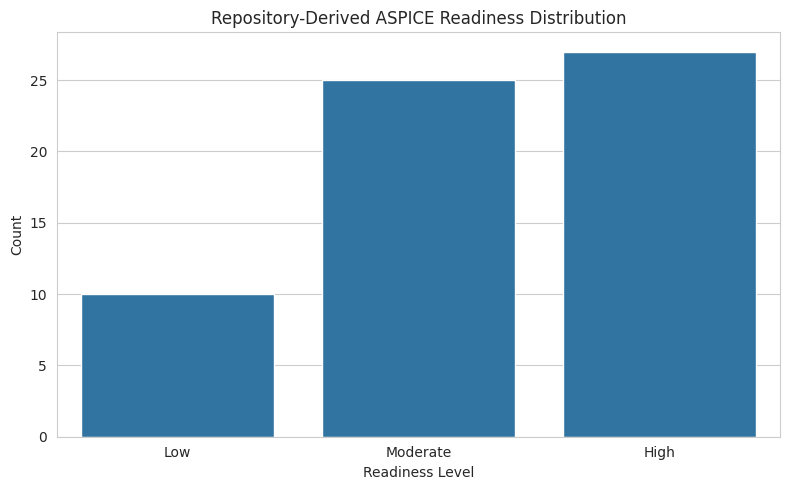

In [14]:
# Class distribution
class_order = ["Low","Moderate","High"]
counts = readiness_df[TARGET_COLUMN].value_counts().reindex(class_order).fillna(0).astype(int)
class_table = pd.DataFrame({
    "Readiness Level": class_order,
    "Count": counts.values,
    "Percentage": counts.values/counts.sum()*100
})
display(class_table.round(2))
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=class_table, x="Readiness Level", y="Count", order=class_order, ax=ax)
ax.set_title("Repository-Derived ASPICE Readiness Distribution")
plt.tight_layout()
plt.savefig(os.path.join(EDA_FIGURE_PATH,"03_class_balance.png"), dpi=300, bbox_inches="tight")
plt.show()

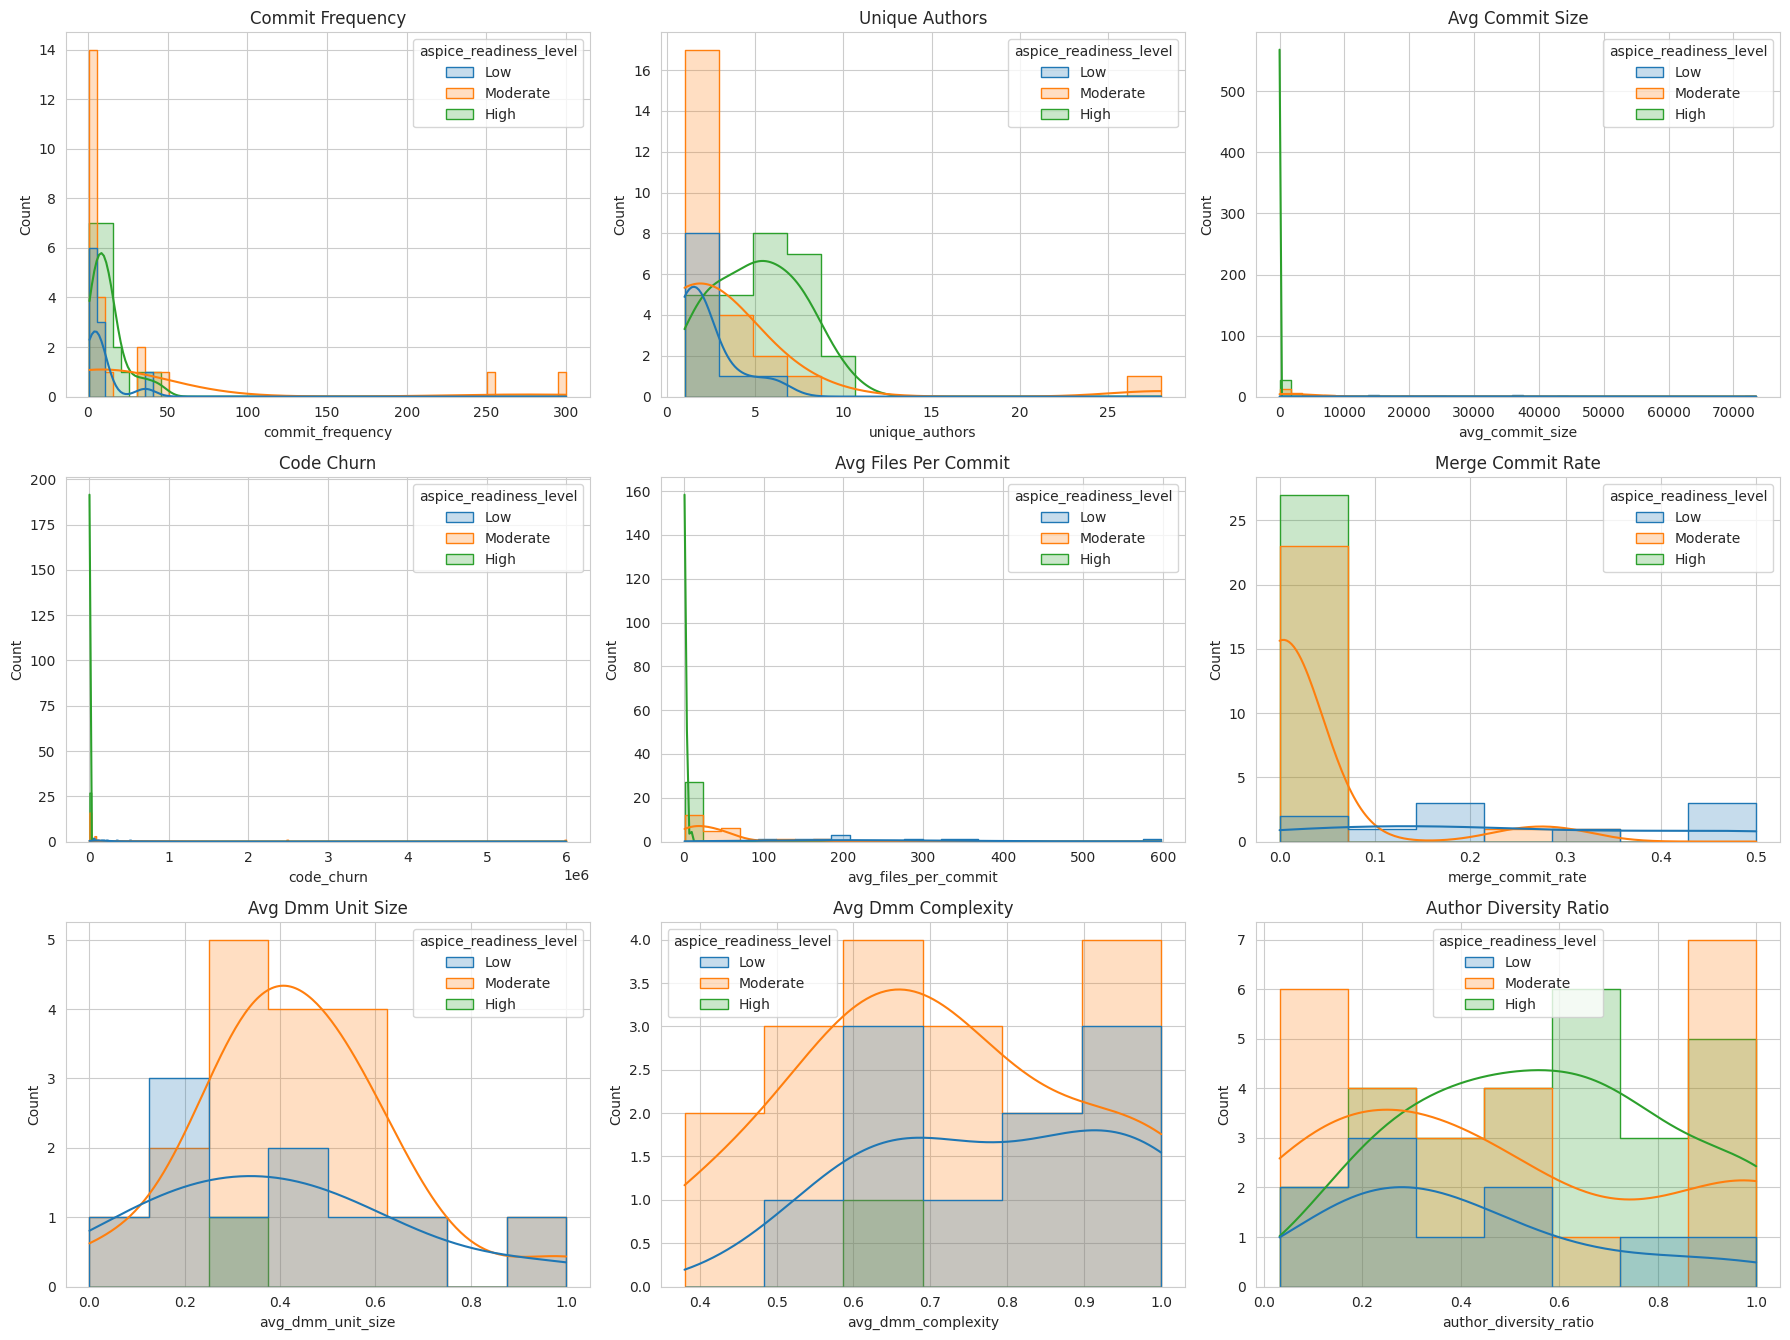

In [15]:
# Feature distributions
ncols = 3
nrows = math.ceil(len(feature_columns)/ncols)
fig, axes = plt.subplots(nrows,ncols,figsize=(18,4.5*nrows))
axes = np.asarray(axes).reshape(-1)
for i,c in enumerate(feature_columns):
    sns.histplot(data=readiness_df, x=c, hue=TARGET_COLUMN, hue_order=class_order,
                 kde=True, element="step", common_norm=False, ax=axes[i])
    axes[i].set_title(c.replace("_"," ").title())
for j in range(len(feature_columns),len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(EDA_FIGURE_PATH,"01_feature_distributions.png"), dpi=300, bbox_inches="tight")
plt.show()

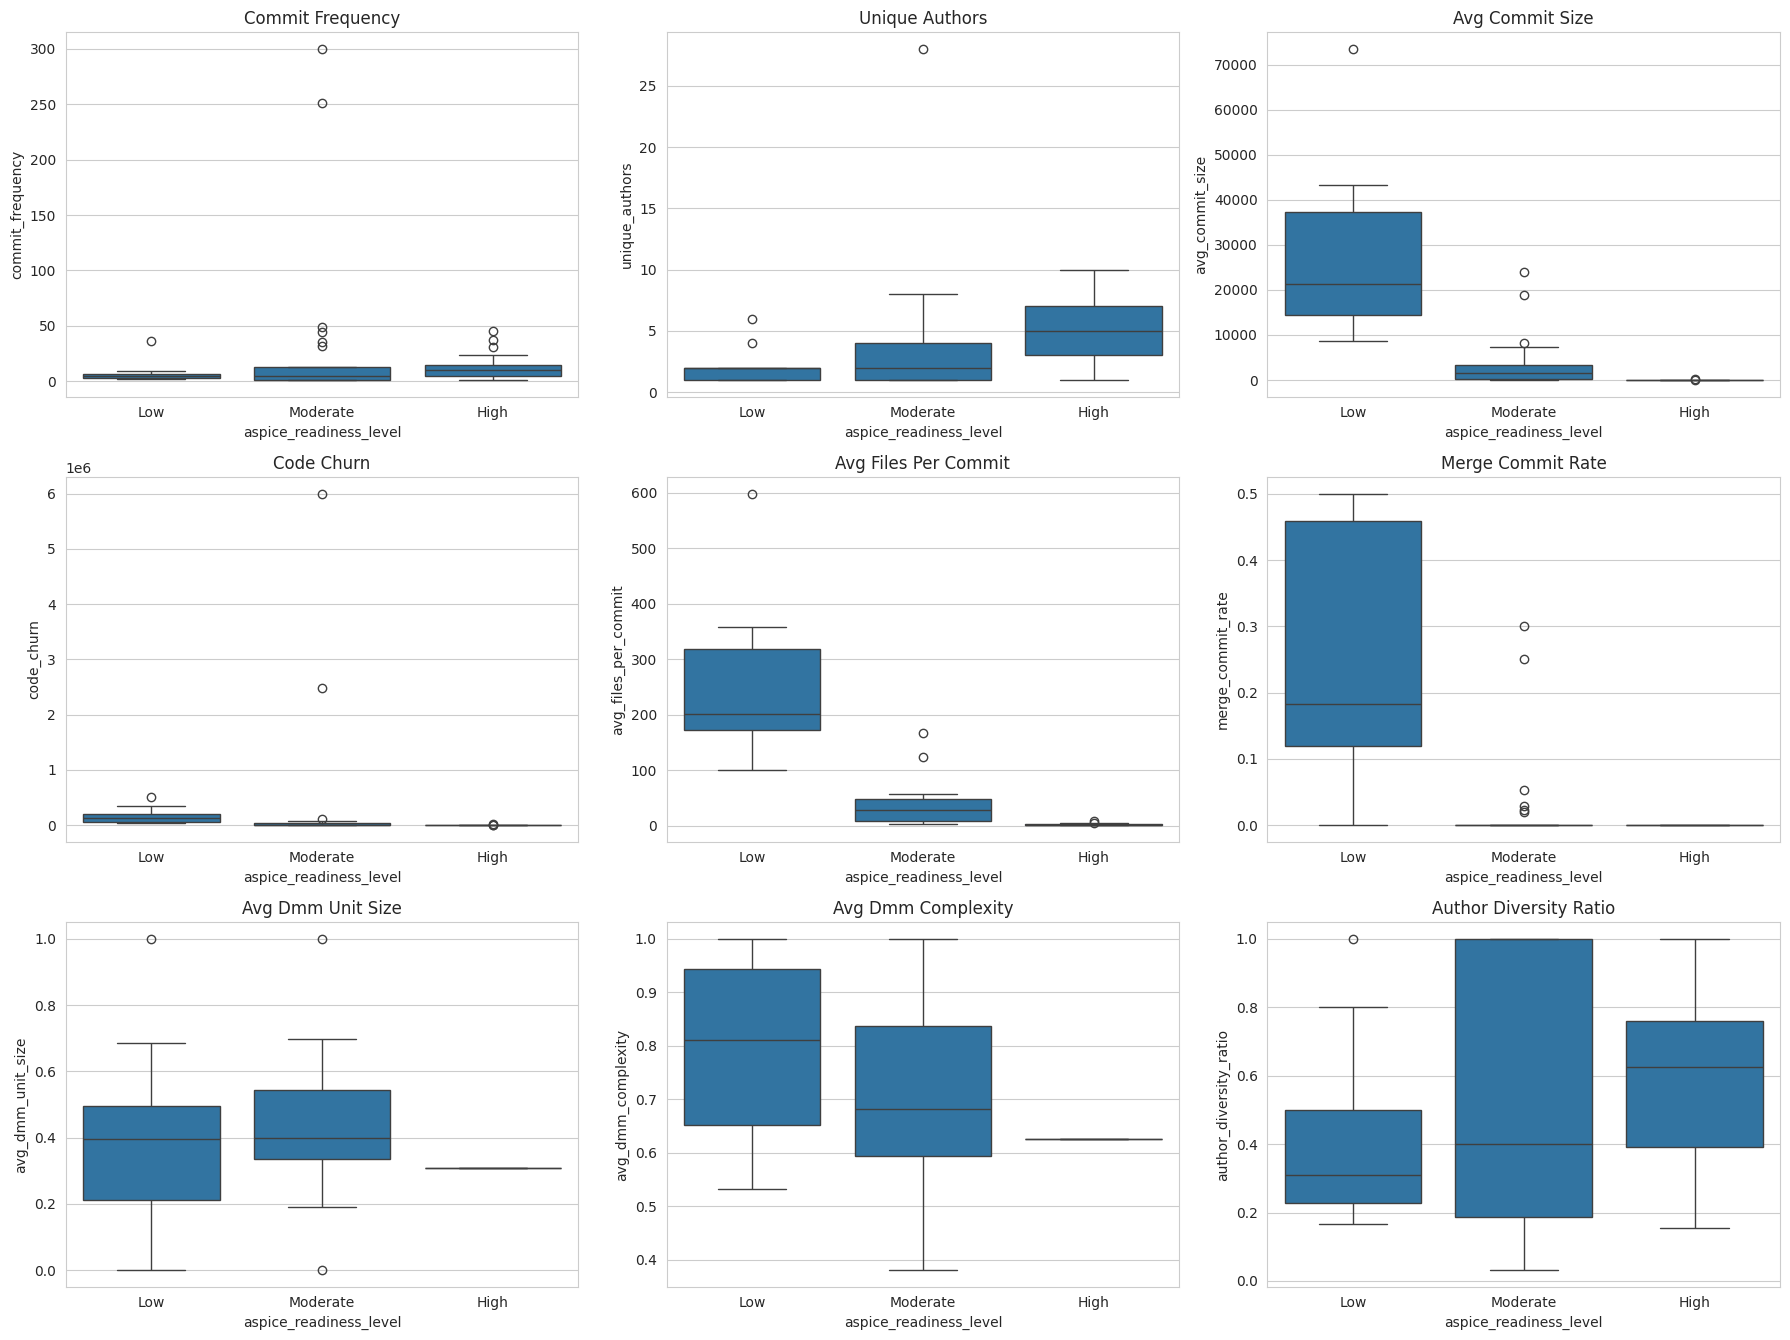

In [16]:
# Boxplots
fig, axes = plt.subplots(nrows,ncols,figsize=(18,4.5*nrows))
axes = np.asarray(axes).reshape(-1)
for i,c in enumerate(feature_columns):
    sns.boxplot(data=readiness_df, x=TARGET_COLUMN, y=c, order=class_order, ax=axes[i])
    axes[i].set_title(c.replace("_"," ").title())
for j in range(len(feature_columns),len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(EDA_FIGURE_PATH,"02_feature_boxplots_by_readiness.png"), dpi=300, bbox_inches="tight")
plt.show()

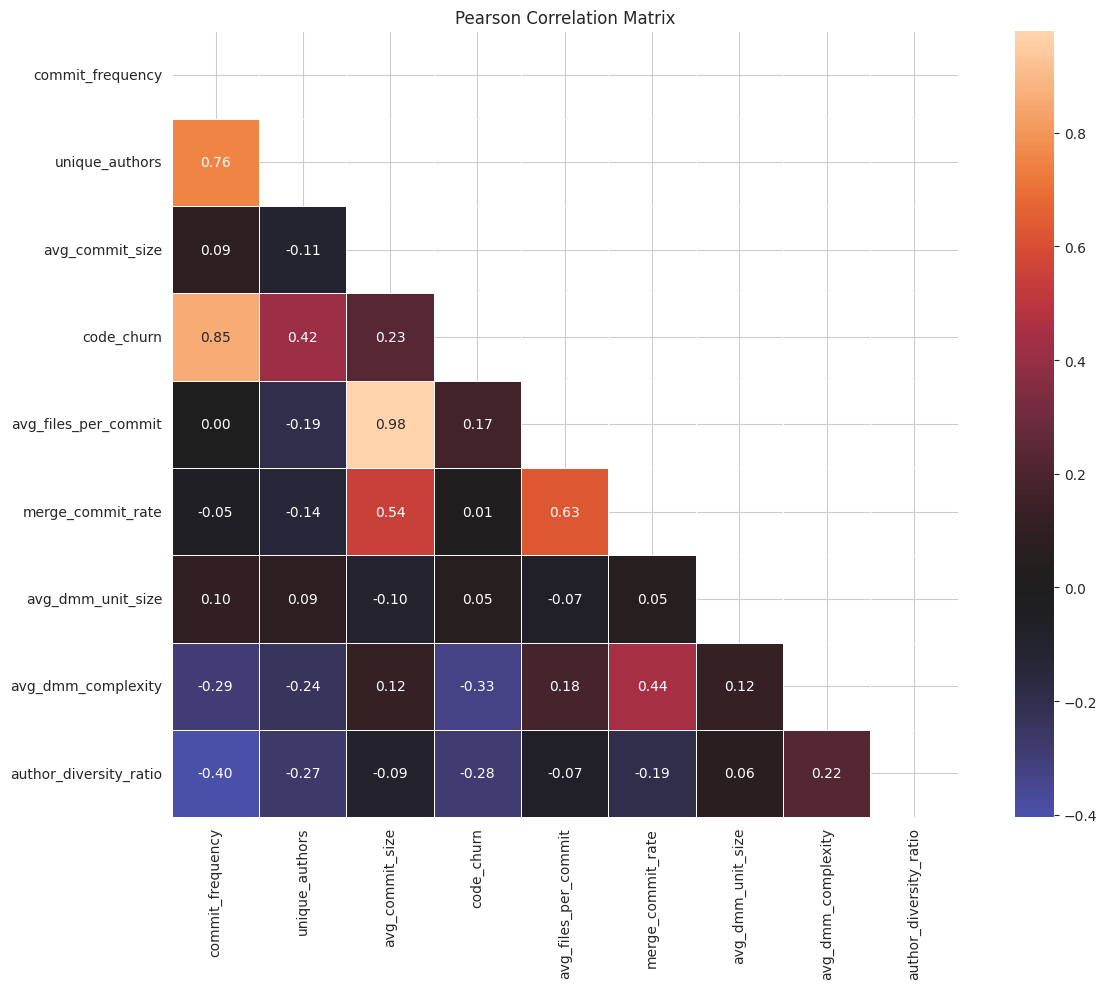

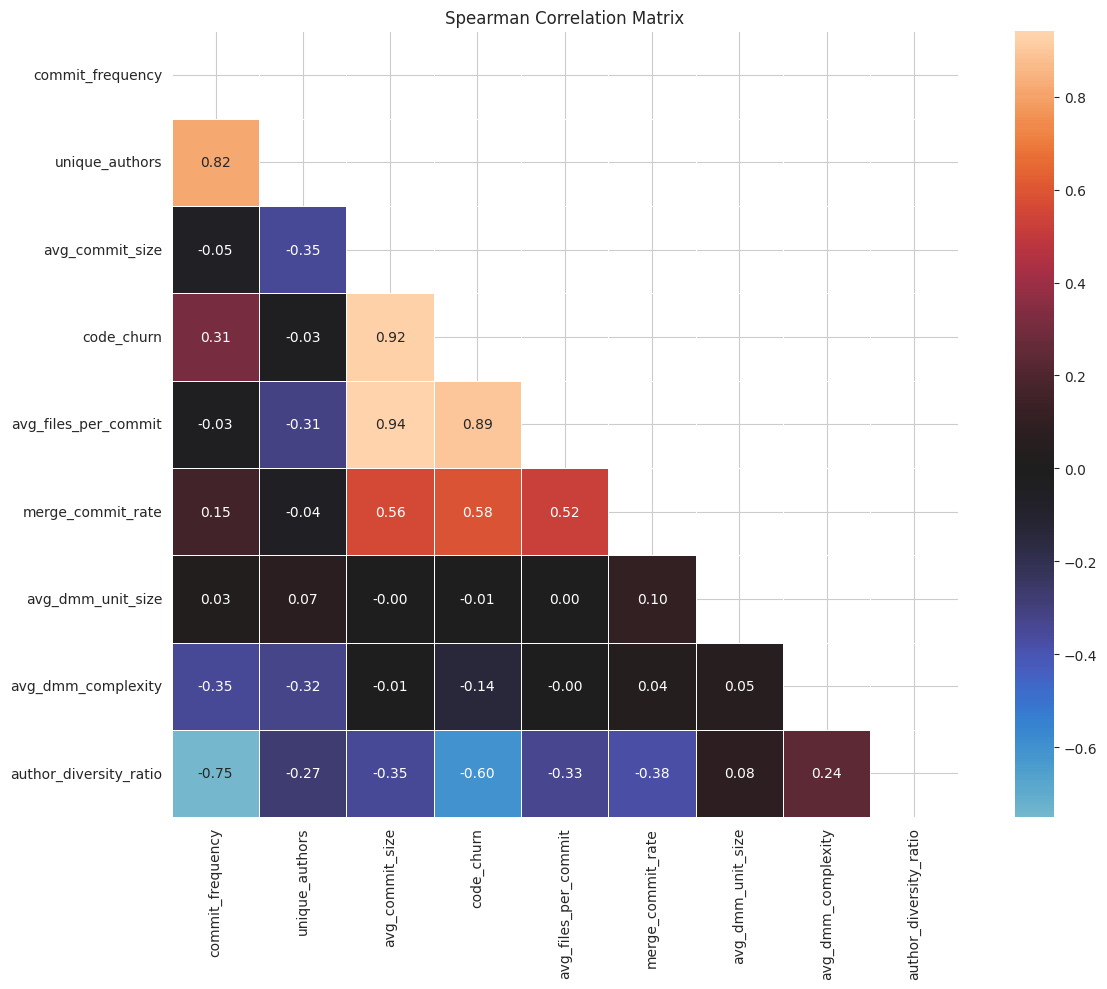

In [17]:
# Correlation heatmaps
corr_data = readiness_df[feature_columns].apply(lambda c: c.fillna(c.median()))
for method, fname in [("pearson","04_pearson_correlation.png"),("spearman","05_spearman_correlation.png")]:
    matrix = corr_data.corr(method=method)
    fig, ax = plt.subplots(figsize=(13,10))
    mask = np.triu(np.ones_like(matrix,dtype=bool))
    sns.heatmap(matrix,mask=mask,annot=True,fmt=".2f",center=0,linewidths=.5,square=True,ax=ax)
    ax.set_title(f"{method.title()} Correlation Matrix")
    plt.tight_layout()
    plt.savefig(os.path.join(EDA_FIGURE_PATH,fname),dpi=300,bbox_inches="tight")
    plt.show()
    matrix.to_csv(os.path.join(EDA_TABLE_PATH,f"{method}_correlation_matrix.csv"))

,Feature,VIF
4,avg_files_per_commit,42.696
2,avg_commit_size,36.839
0,commit_frequency,16.335
3,code_churn,8.463
1,unique_authors,4.780
5,merge_commit_rate,2.820
7,avg_dmm_complexity,1.694
8,author_diversity_ratio,1.547
6,avg_dmm_unit_size,1.106


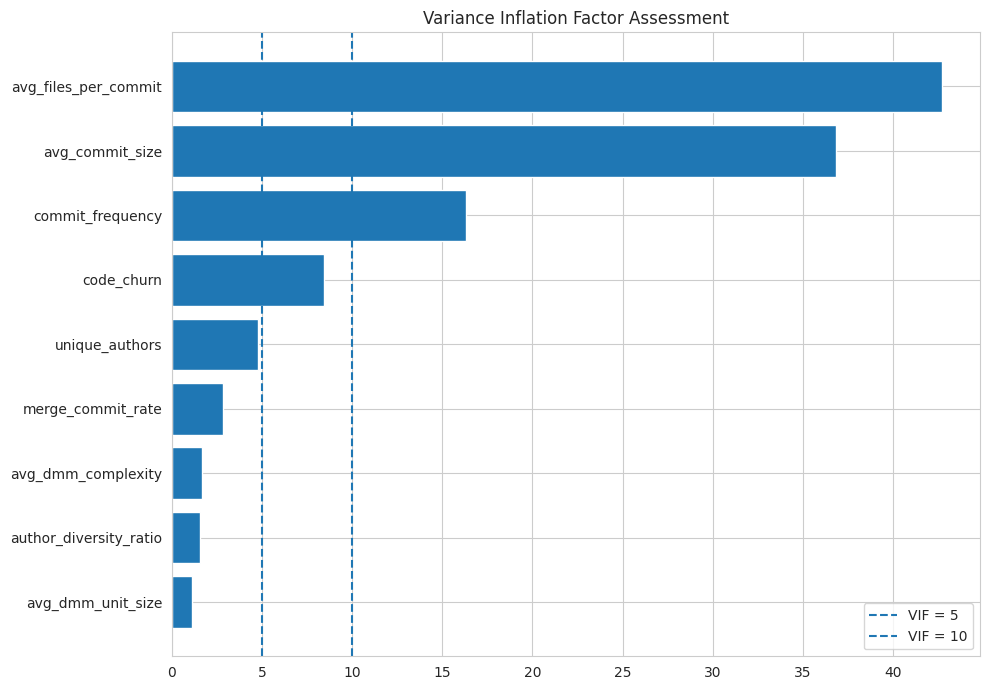

In [18]:
# VIF
vif_data = readiness_df[feature_columns].apply(lambda c: c.fillna(c.median()))
scaled = StandardScaler().fit_transform(vif_data)
vif_rows = []
for i,c in enumerate(feature_columns):
    try:
        v = variance_inflation_factor(scaled,i)
    except Exception:
        v = np.nan
    vif_rows.append({"Feature":c,"VIF":v})
vif_table = pd.DataFrame(vif_rows).sort_values("VIF",ascending=False)
display(vif_table.round(3))
fig, ax = plt.subplots(figsize=(10,7))
p = vif_table.sort_values("VIF")
ax.barh(p["Feature"],p["VIF"])
ax.axvline(5,linestyle="--",label="VIF = 5")
ax.axvline(10,linestyle="--",label="VIF = 10")
ax.legend()
ax.set_title("Variance Inflation Factor Assessment")
plt.tight_layout()
plt.savefig(os.path.join(EDA_FIGURE_PATH,"06_vif_multicollinearity.png"),dpi=300,bbox_inches="tight")
plt.show()
vif_table.to_csv(os.path.join(EDA_TABLE_PATH,"07_vif_multicollinearity.csv"),index=False)

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,commit_frequency,-12.000,28.000,10,16.129
1,unique_authors,-5.000,11.000,1,1.613
2,avg_commit_size,-5104.709,8566.266,12,19.355
3,code_churn,-61695.375,103201.625,8,12.903
4,avg_files_per_commit,-67.750,118.250,11,17.742
5,merge_commit_rate,0.000,0.000,14,22.581
6,avg_dmm_unit_size,0.005,0.815,4,6.452
7,avg_dmm_complexity,0.246,1.265,0,0.000
8,author_diversity_ratio,-0.517,1.533,0,0.000


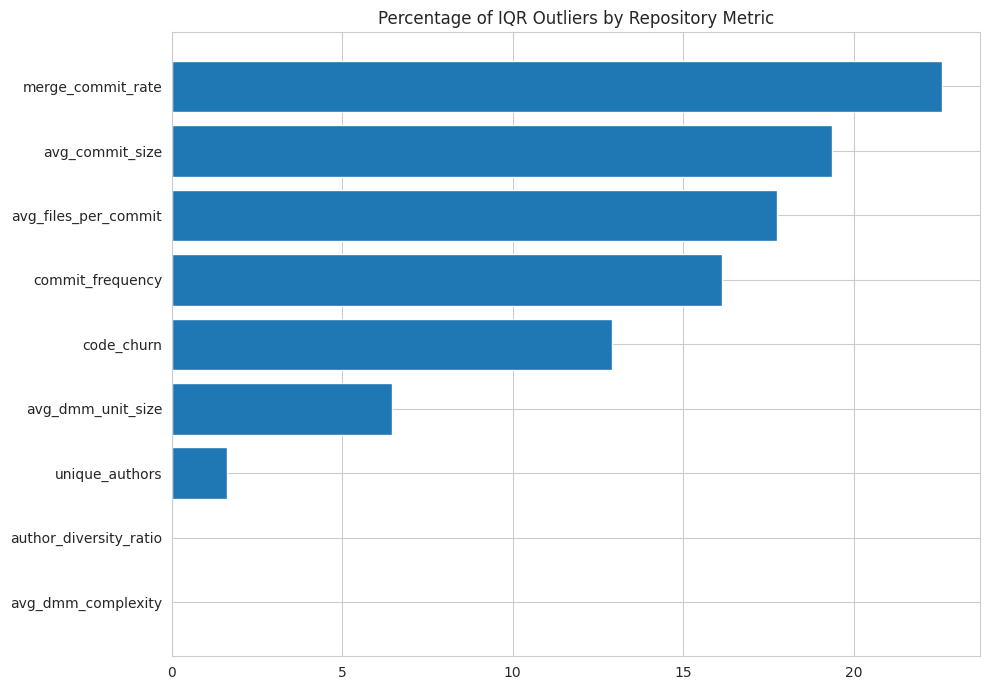

In [19]:
# Outliers
outlier_rows = []
for c in feature_columns:
    x = readiness_df[c].dropna()
    q1,q3 = x.quantile(.25),x.quantile(.75)
    iqr = q3-q1
    lo,hi = q1-1.5*iqr,q3+1.5*iqr
    mask = (readiness_df[c]<lo)|(readiness_df[c]>hi)
    outlier_rows.append({
        "Feature":c,"Lower Bound":lo,"Upper Bound":hi,
        "Outlier Count":int(mask.sum()),"Outlier Percentage":mask.mean()*100
    })
outliers = pd.DataFrame(outlier_rows)
display(outliers.round(3))
fig, ax = plt.subplots(figsize=(10,7))
p = outliers.sort_values("Outlier Percentage")
ax.barh(p["Feature"],p["Outlier Percentage"])
ax.set_title("Percentage of IQR Outliers by Repository Metric")
plt.tight_layout()
plt.savefig(os.path.join(EDA_FIGURE_PATH,"07_outlier_percentages.png"),dpi=300,bbox_inches="tight")
plt.show()
outliers.to_csv(os.path.join(EDA_TABLE_PATH,"08_outlier_summary.csv"),index=False)

,Feature,Mutual Information
2,avg_commit_size,0.8547
4,avg_files_per_commit,0.6582
3,code_churn,0.4508
5,merge_commit_rate,0.3114
6,avg_dmm_unit_size,0.2233
7,avg_dmm_complexity,0.2030
1,unique_authors,0.1495
0,commit_frequency,0.1322
8,author_diversity_ratio,0.1005


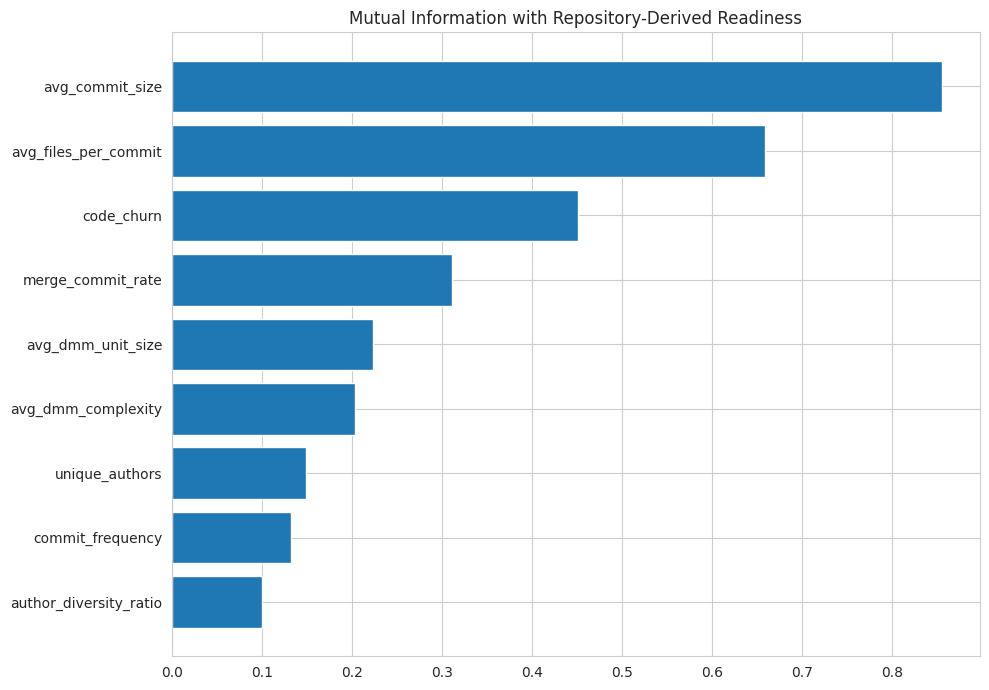

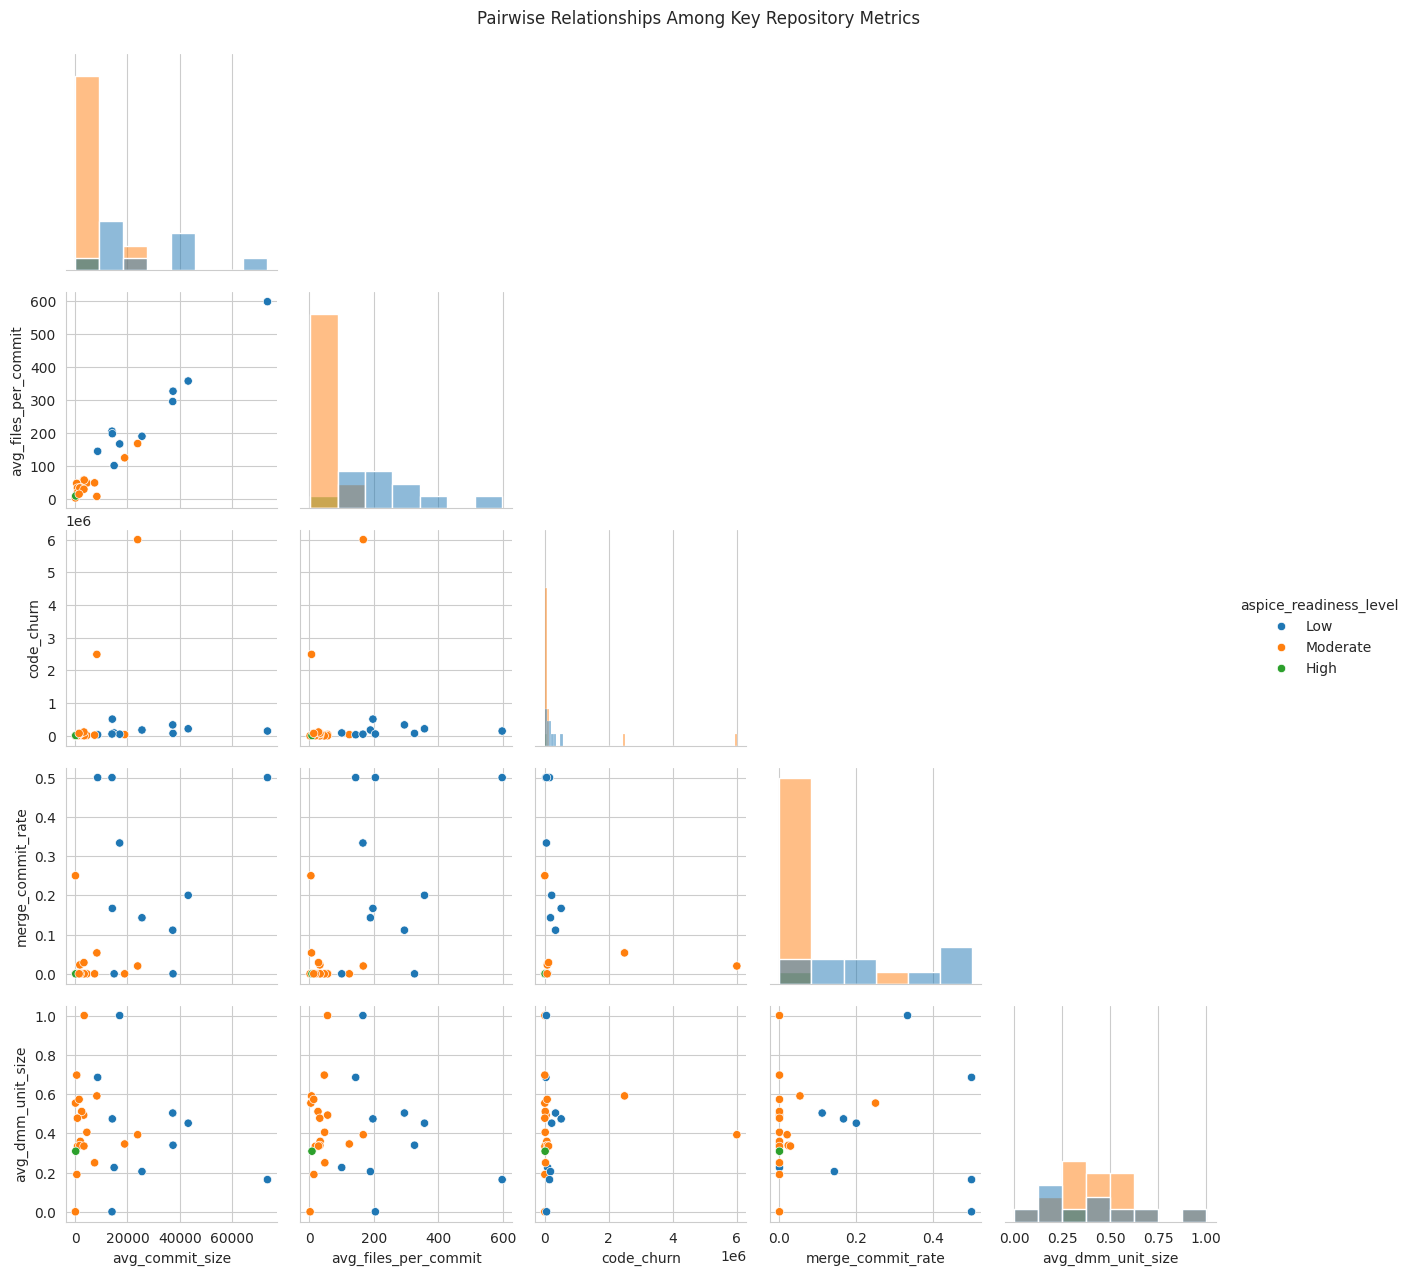

In [20]:
# Mutual information and pair plot
X = readiness_df[feature_columns].apply(lambda c: c.fillna(c.median()))
y = LabelEncoder().fit_transform(readiness_df[TARGET_COLUMN].astype(str))
mi = mutual_info_classif(X,y,random_state=42)
mi_table = pd.DataFrame({"Feature":feature_columns,"Mutual Information":mi}).sort_values("Mutual Information",ascending=False)
display(mi_table.round(4))

fig, ax = plt.subplots(figsize=(10,7))
p = mi_table.sort_values("Mutual Information")
ax.barh(p["Feature"],p["Mutual Information"])
ax.set_title("Mutual Information with Repository-Derived Readiness")
plt.tight_layout()
plt.savefig(os.path.join(EDA_FIGURE_PATH,"08_mutual_information.png"),dpi=300,bbox_inches="tight")
plt.show()

top = mi_table.head(min(5,len(mi_table)))["Feature"].tolist()
pair_data = readiness_df[top+[TARGET_COLUMN]].dropna()
if len(pair_data) >= 5 and len(top) >= 2:
    grid = sns.pairplot(pair_data,hue=TARGET_COLUMN,hue_order=class_order,corner=True,diag_kind="hist")
    grid.fig.suptitle("Pairwise Relationships Among Key Repository Metrics",y=1.02)
    grid.savefig(os.path.join(EDA_FIGURE_PATH,"10_pairwise_repository_metrics.png"),dpi=300,bbox_inches="tight")
    plt.show()

In [21]:
print("="*80)
print("WORKFLOW COMPLETED")
print("="*80)
print(f"Commit records: {len(pipeline_results['commit_dataset'])}")
print(f"Repository observations: {len(df)}")
print(f"Readiness observations: {len(readiness_df)}")
print(f"Repositories: {list(readiness_df['repository_name'].unique())}")
print(f"Figures saved to: {EDA_FIGURE_PATH}")
print(f"Tables saved to: {EDA_TABLE_PATH}")

WORKFLOW COMPLETED
Commit records: 1200
Repository observations: 62
Readiness observations: 62
Repositories: ['apollo', 'autoware', 'opSimulation', 'sumo']
Figures saved to: ./figures/repository_eda
Tables saved to: ./tables/repository_eda
